## Exercise 5 

In [2]:
import csv

data = []

with open("Movies.csv", "r", encoding="utf-8") as file:
    reader = csv.DictReader(file)

    for row in reader:
        data.append(row)

print(len(data))
print(data[0])

7787
{'show_id': 's1', 'type': 'TV Show', 'title': '3%', 'director': '', 'cast': 'João Miguel, Bianca Comparato, Michel Gomes, Rodolfo Valente, Vaneza Oliveira, Rafael Lozano, Viviane Porto, Mel Fronckowiak, Sergio Mamberti, Zezé Motta, Celso Frateschi', 'country': 'Brazil', 'date_added': 'August 14, 2020', 'release_year': '2020', 'rating': 'TV-MA', 'duration': '4 Seasons', 'listed_in': 'International TV Shows, TV Dramas, TV Sci-Fi & Fantasy', 'description': 'In a future where the elite inhabit an island paradise far from the crowded slums, you get one chance to join the 3% saved from squalor.'}


In [20]:
rating_map = {
    "G": 0,
    "TV-Y": 7,
    "TV-Y7": 7,
    "PG": 10,
    "TV-PG": 10,
    "PG-13": 13,
    "TV-14": 14,
    "R": 17,
    "NC-17": 18,
    "TV-MA": 18,
    "NR": 0,
    "UR": 0,
    "TV-Y7-FV": 7
}

In [21]:
numeric_ratings = []

for d in data:
    r = d["rating"]

    if r in rating_map :
        numeric_ratings.append(rating_map[r])

In [22]:
for d in data:
    r = d["rating"]

    d["RatingNumeric"] = rating_map.get(r)

In [23]:
print(data[0].keys())

dict_keys(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'RatingNumeric'])


### Q1.  Compute mean, standard deviation, min, and max of the Rating field.


In [26]:
import numpy as np

ratings = []

for d in data:
    if d["RatingNumeric"] is not None:
        ratings.append(d["RatingNumeric"])

rate = np.array(ratings, dtype=float)

# Statistics
mean_rating = np.mean(rate)
std_dev = np.std(rate)
min_rating = np.min(rate)
max_rating = np.max(rate)

print("Mean:", mean_rating)
print("Std Dev:", std_dev)
print("Min:", min_rating)
print("Max:", max_rating)

Mean: 14.417875032955445
Std Dev: 3.9794379250076375
Min: 0.0
Max: 18.0


### Q2.  Plot a histogram of the Rating field using Matplotlib.


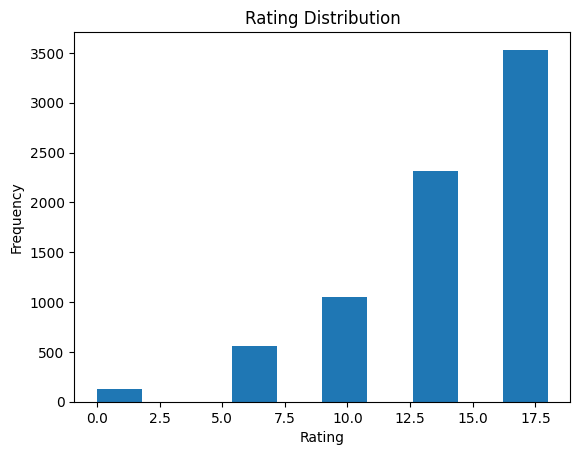

In [32]:
import matplotlib.pyplot as plt

plt.hist(ratings, bins=10)

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Rating Distribution")

plt.show()

### Q3. Find the mean rating grouped by Country and plot them as a bar chart.


In [40]:
import numpy as np
import matplotlib.pyplot as plt

country_ratings = {}

for movie in data:

    country_field = movie["country"]
    rating = movie["RatingNumeric"]

    if not country_field or rating is None:
        continue

    countries = [c.strip() for c in country_field.split(",")]

    for country in countries:
        if country not in country_ratings:
            country_ratings[country] = []

        country_ratings[country].append(float(rating))

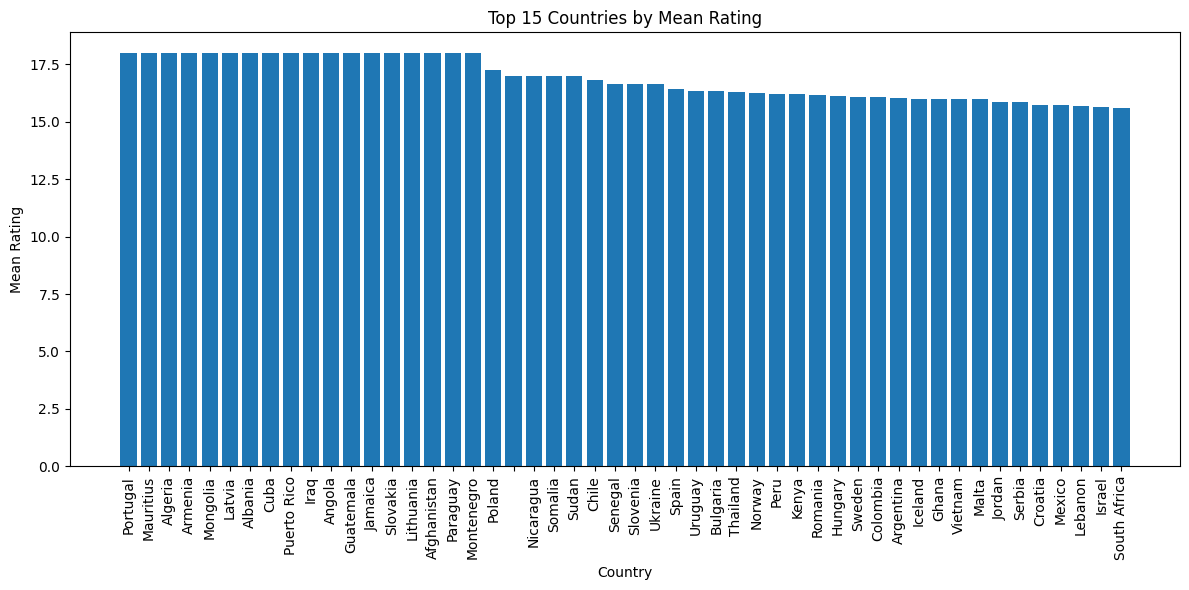

In [53]:
# country_mean = {
#     country: np.mean(values)
#     for country, values in country_ratings.items()
# }
country_mean = {
    country: np.mean(values)
    for country, values in country_ratings.items()
    if len(values) >= 0      
}
sorted_countries = sorted(
    country_mean.items(),
    key=lambda x: x[1],
    reverse=True
)

top50 = sorted_countries[:50]

countries = [x[0] for x in top50]
means = [x[1] for x in top50]

plt.figure(figsize=(12,6))

plt.bar(countries, means)

plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Mean Rating")
plt.title("Top 15 Countries by Mean Rating")

plt.tight_layout()
plt.show()

### Q4. Find the minimum and maximum duration grouped by Year.


In [ ]:
year_duration = {}

for movie in data:

    if movie["type"] != "Movie":
        continue

    year = movie["release_year"]
    duration = movie["duration"]

    if not year or not duration:
        continue

    if "min" in duration:
        minutes = int(duration.split()[0])

        if year not in year_duration:
            year_duration[year] = []

        year_duration[year].append(minutes)

In [56]:
year_min_max = {}

for year, durations in year_duration.items():
    year_min_max[year] = {
        "min": min(durations),
        "max": max(durations)
    }

print(year_min_max)

{'2016': {'min': 22, 'max': 173}, '2011': {'min': 24, 'max': 164}, '2009': {'min': 29, 'max': 203}, '2008': {'min': 25, 'max': 214}, '2019': {'min': 10, 'max': 209}, '1997': {'min': 87, 'max': 187}, '2017': {'min': 11, 'max': 166}, '2018': {'min': 12, 'max': 312}, '2014': {'min': 3, 'max': 190}, '2015': {'min': 12, 'max': 205}, '2020': {'min': 5, 'max': 190}, '2010': {'min': 23, 'max': 186}, '2005': {'min': 55, 'max': 208}, '2012': {'min': 23, 'max': 172}, '2006': {'min': 45, 'max': 196}, '2013': {'min': 22, 'max': 180}, '2000': {'min': 56, 'max': 165}, '2003': {'min': 37, 'max': 201}, '1989': {'min': 72, 'max': 192}, '2004': {'min': 46, 'max': 185}, '1977': {'min': 84, 'max': 176}, '1971': {'min': 100, 'max': 181}, '1993': {'min': 56, 'max': 195}, '2007': {'min': 70, 'max': 169}, '1998': {'min': 31, 'max': 185}, '1988': {'min': 48, 'max': 148}, '1996': {'min': 81, 'max': 204}, '2002': {'min': 78, 'max': 179}, '1986': {'min': 80, 'max': 162}, '1990': {'min': 30, 'max': 174}, '1979': {'

### Q5. Calculate average duration of movies yearwise , then plot them using both Matplotlib and Seaborn.


In [57]:
import numpy as np

avg_duration_year = {
    year: np.mean(durations)
    for year, durations in year_duration.items()
}

years = sorted(avg_duration_year.keys())
avg_durations = [avg_duration_year[y] for y in years]




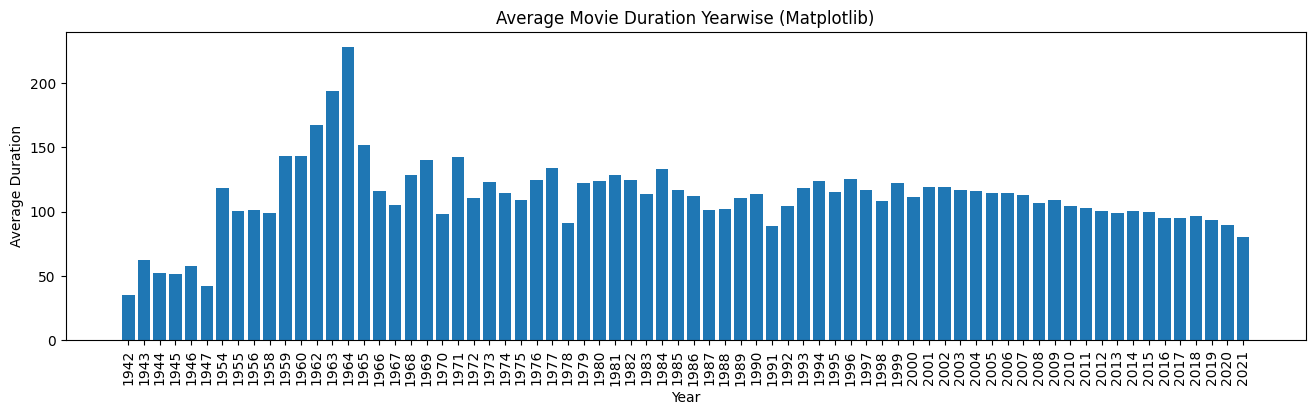

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
plt.bar(years, avg_durations)
plt.xticks(rotation=90)
plt.xlabel("Year")
plt.ylabel("Average Duration")
plt.title("Average Movie Duration Yearwise (Matplotlib)")

plt.show()

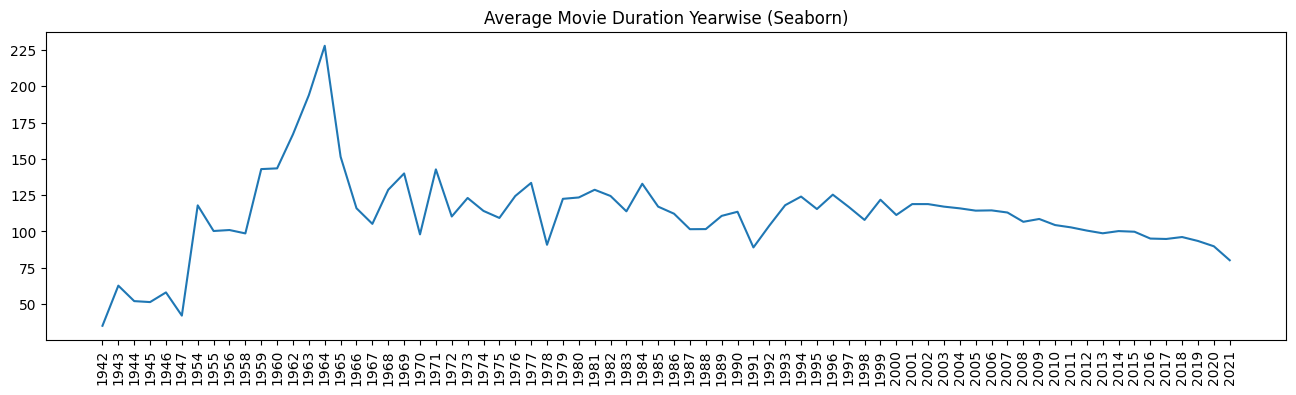

In [67]:
import seaborn as sns

plt.figure(figsize=(16, 4))
sns.lineplot(x=years, y=avg_durations)
plt.xticks(rotation=90)
plt.title("Average Movie Duration Yearwise (Seaborn)")
plt.show()

### Q6.Generate box plots for Rating, duration, and ReleaseYear.


In [68]:
ratings = []
durations = []
years_numeric = []

for movie in data:

    if movie["RatingNumeric"] is not None:
        ratings.append(movie["RatingNumeric"])

    if movie["type"] == "Movie" and movie["duration"]:
        if "min" in movie["duration"]:
            durations.append(int(movie["duration"].split()[0]))

    if movie["release_year"]:
        years_numeric.append(int(movie["release_year"]))

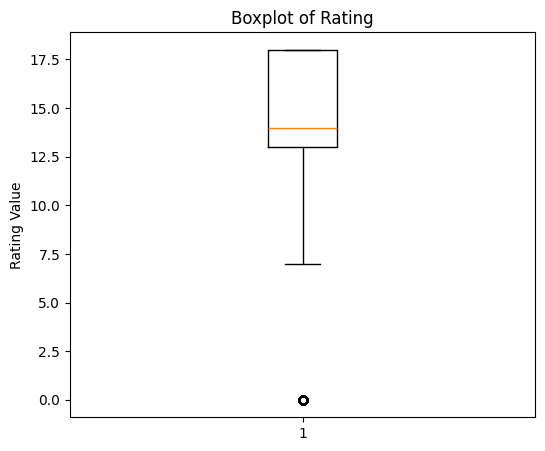

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.boxplot(ratings)

plt.title("Boxplot of Rating")
plt.ylabel("Rating Value")

plt.show()

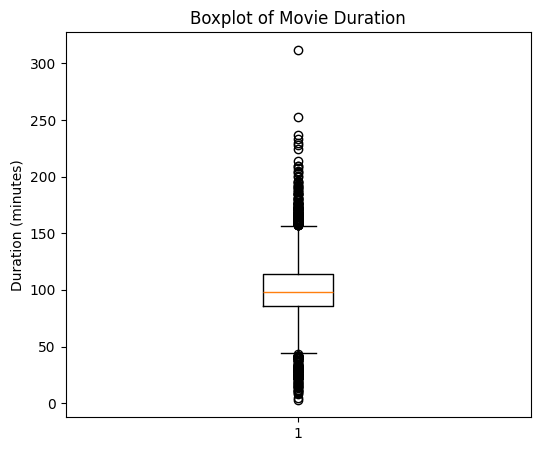

In [71]:
plt.figure(figsize=(6,5))

plt.boxplot(durations)

plt.title("Boxplot of Movie Duration")
plt.ylabel("Duration (minutes)")

plt.show()

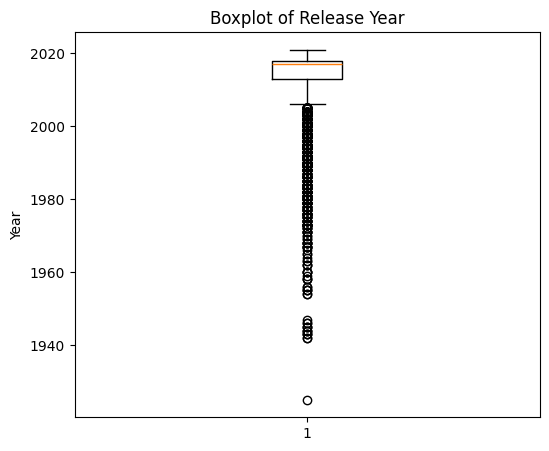

In [72]:
plt.figure(figsize=(6,5))

plt.boxplot(years_numeric)

plt.title("Boxplot of Release Year")
plt.ylabel("Year")

plt.show()

### Q7. Use Seaborn’s factorplot (or catplot) to analyze how Rating varies across Genre and Country.

In [73]:
genres = []
countries = []
rating_values = []

for movie in data:

    rating = movie["RatingNumeric"]
    genre_field = movie["listed_in"]
    country_field = movie["country"]

    if rating is None or not genre_field or not country_field:
        continue

    genre_list = [g.strip() for g in genre_field.split(",")]
    country_list = [c.strip() for c in country_field.split(",")]

    for g in genre_list:
        for c in country_list:
            genres.append(g)
            countries.append(c)
            rating_values.append(rating)

In [74]:
import pandas as pd

df = pd.DataFrame({
    "Genre": genres,
    "Country": countries,
    "Rating": rating_values
})

C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\seaborn\axisgrid.py:123: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


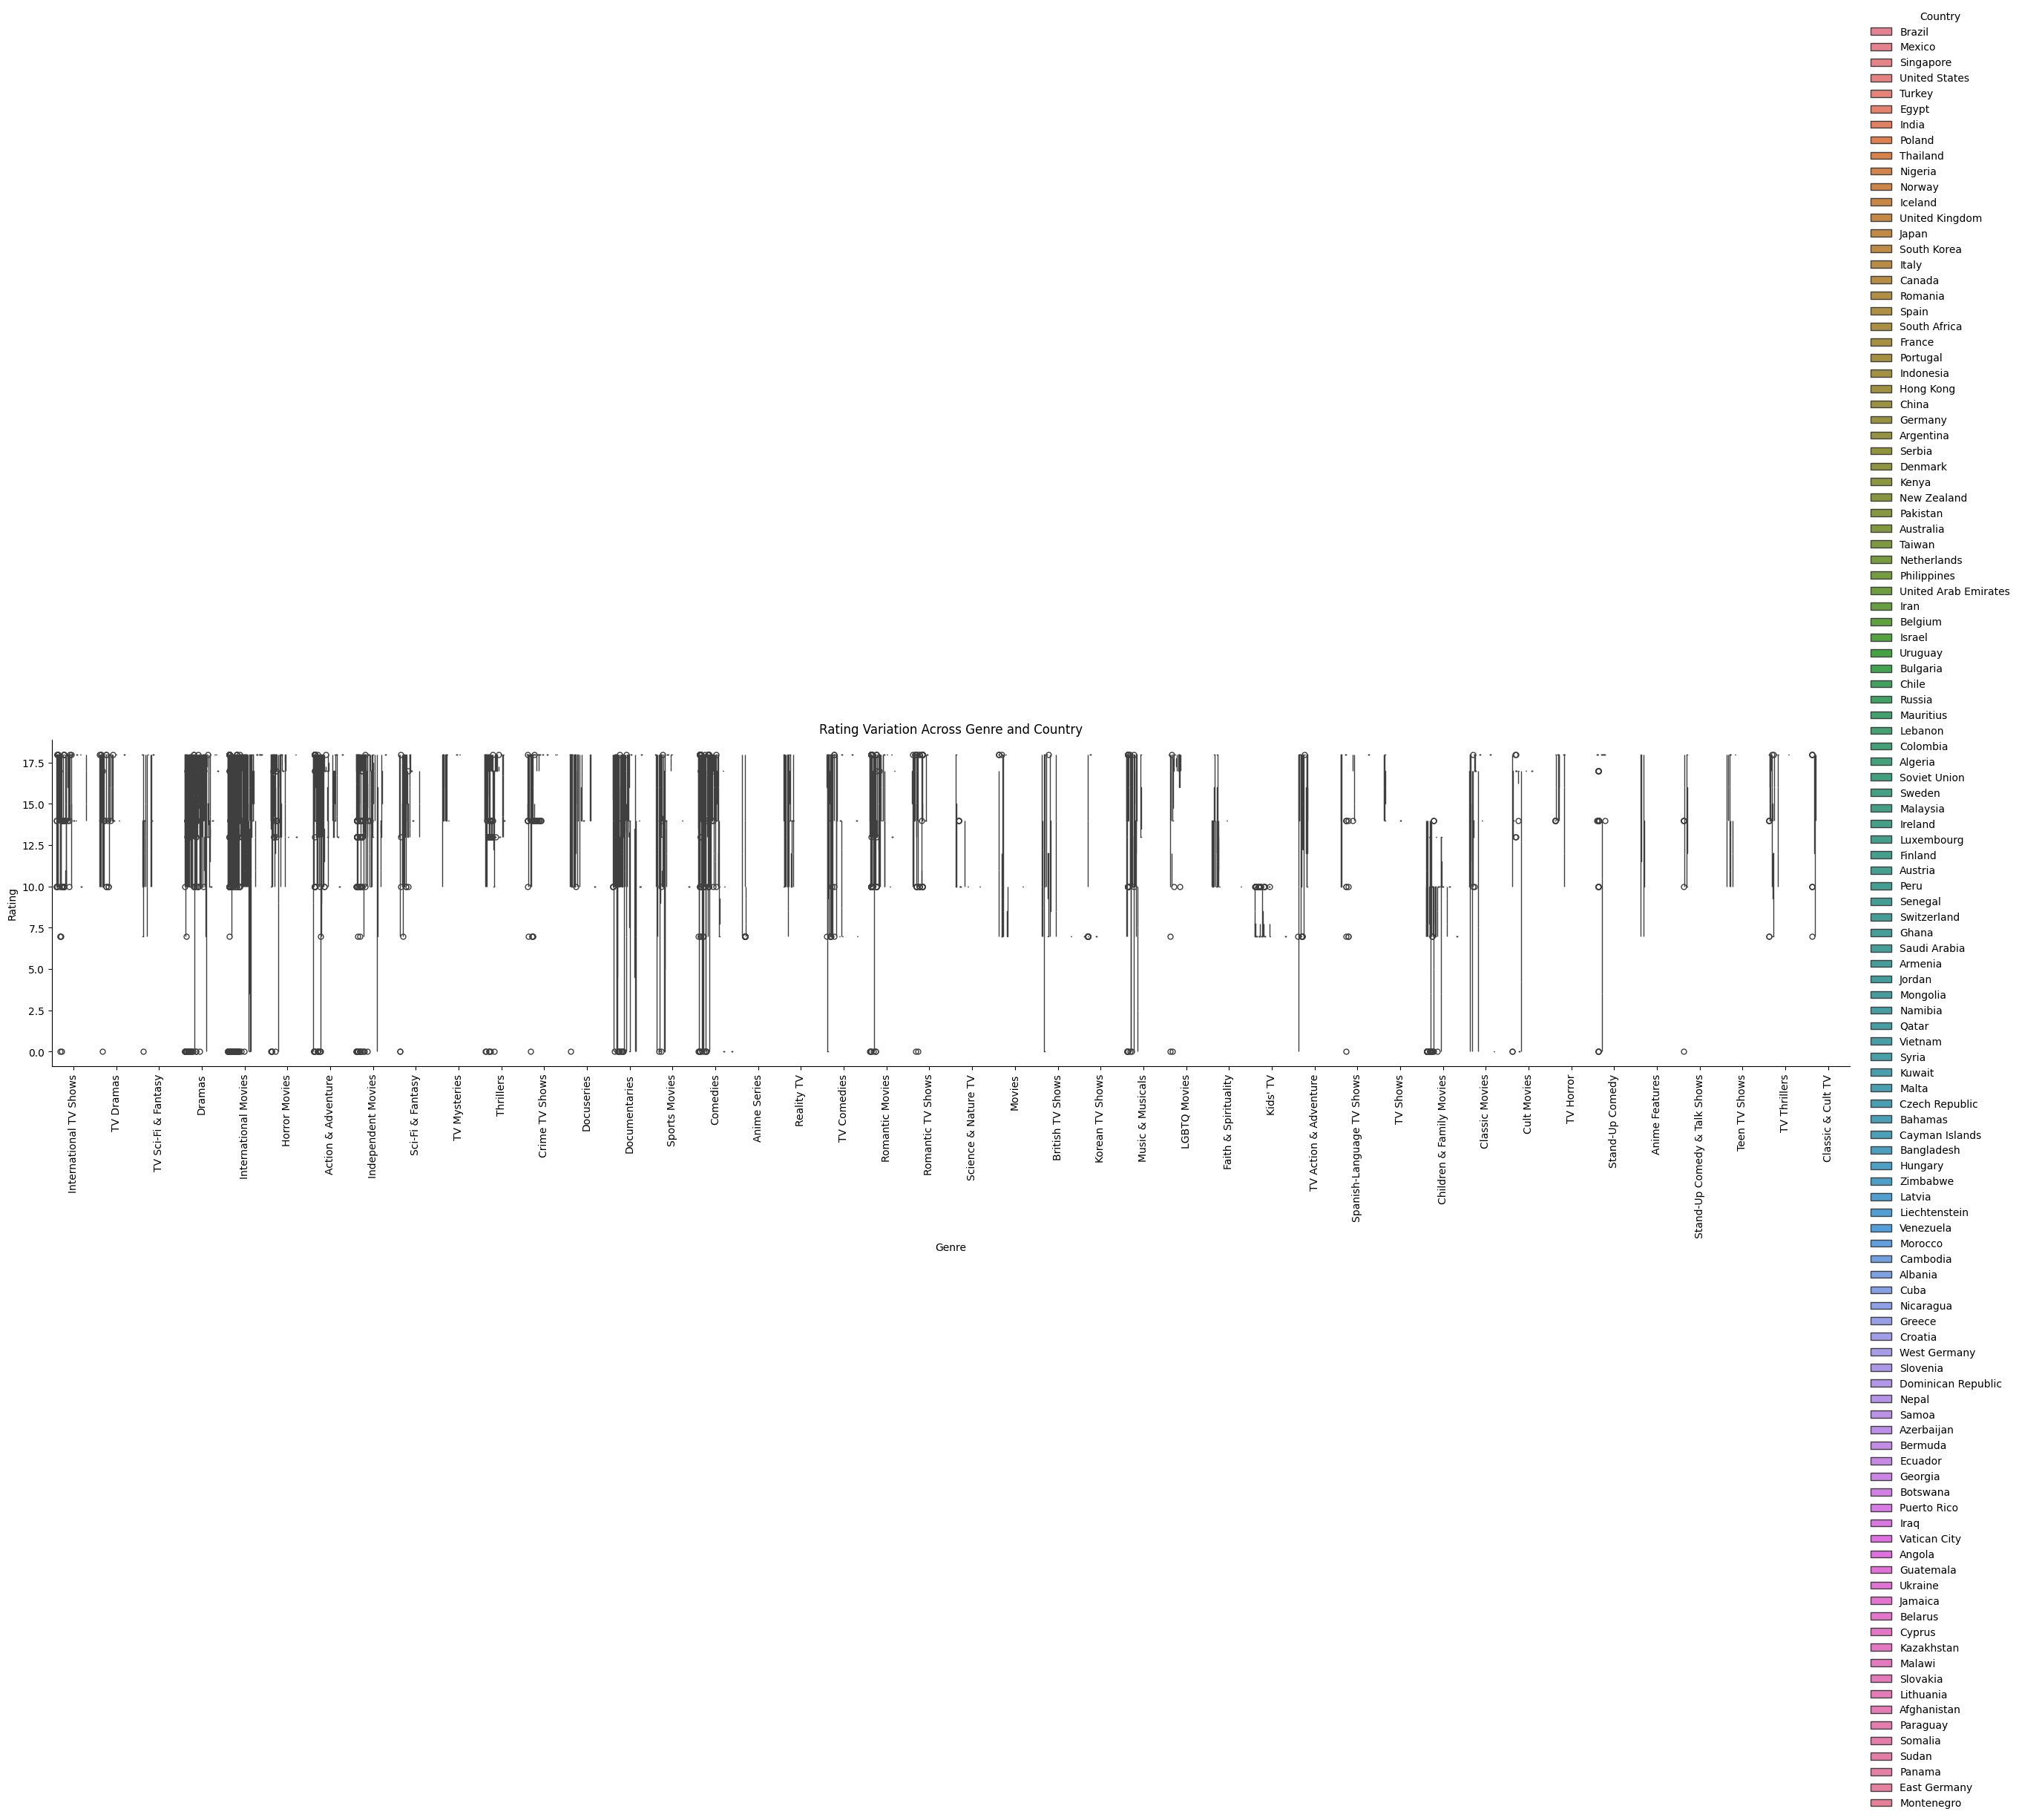

In [76]:
sns.catplot(
    data=df,
    x="Genre",
    y="Rating",
    hue="Country",
    kind="box",
    height=5,
    aspect=5
)

plt.xticks(rotation=90)
plt.title("Rating Variation Across Genre and Country")

plt.show()